### Regenerating Figure 2B

To reproduce **Figure 2B** from the paper, run the script provided below.

#### Prerequisites

Before running this analysis, generate the required single-cell and cell-type-level Hi-C contact matrices (`.cool` files) using the preprocessing workflow described in the `preprocessing/` directory of this repository.

You will also need the cell type annotation file:

* `data/non_neuron.tsv`

This file contains the mapping between cell barcodes and cell types.


#### Update File Paths

Replace the example paths below with the locations of your own files:



In [15]:

bulk_cool_path = '/path/to/OPC.cool'                     # Cell-type-level .cool file
single_cell_cool_dir = '/path/to/single_cell_cools/'    # Directory containing single-cell .cool files
barcode_celltype_tsv = '/path/to/non_neuron.tsv'        # Cell barcode and cell type annotations




#### Selecting a Cell Type

To generate the embedding for a different cell type, modify the following variable:



In [18]:

cell_type = 'OPC'




Supported cell types depend on the entries available in `non_neuron.tsv`.

Selected barcode for OPC: AAACTCGCACTCCCAT
Bulk resolution: 500000 bp
Single-cell resolution: 500000 bp
Bulk matrix shape: (391, 391)
Single-cell matrix shape: (391, 391)
Figure saved: OPC_vs_single_cell_heatmaps.pdf


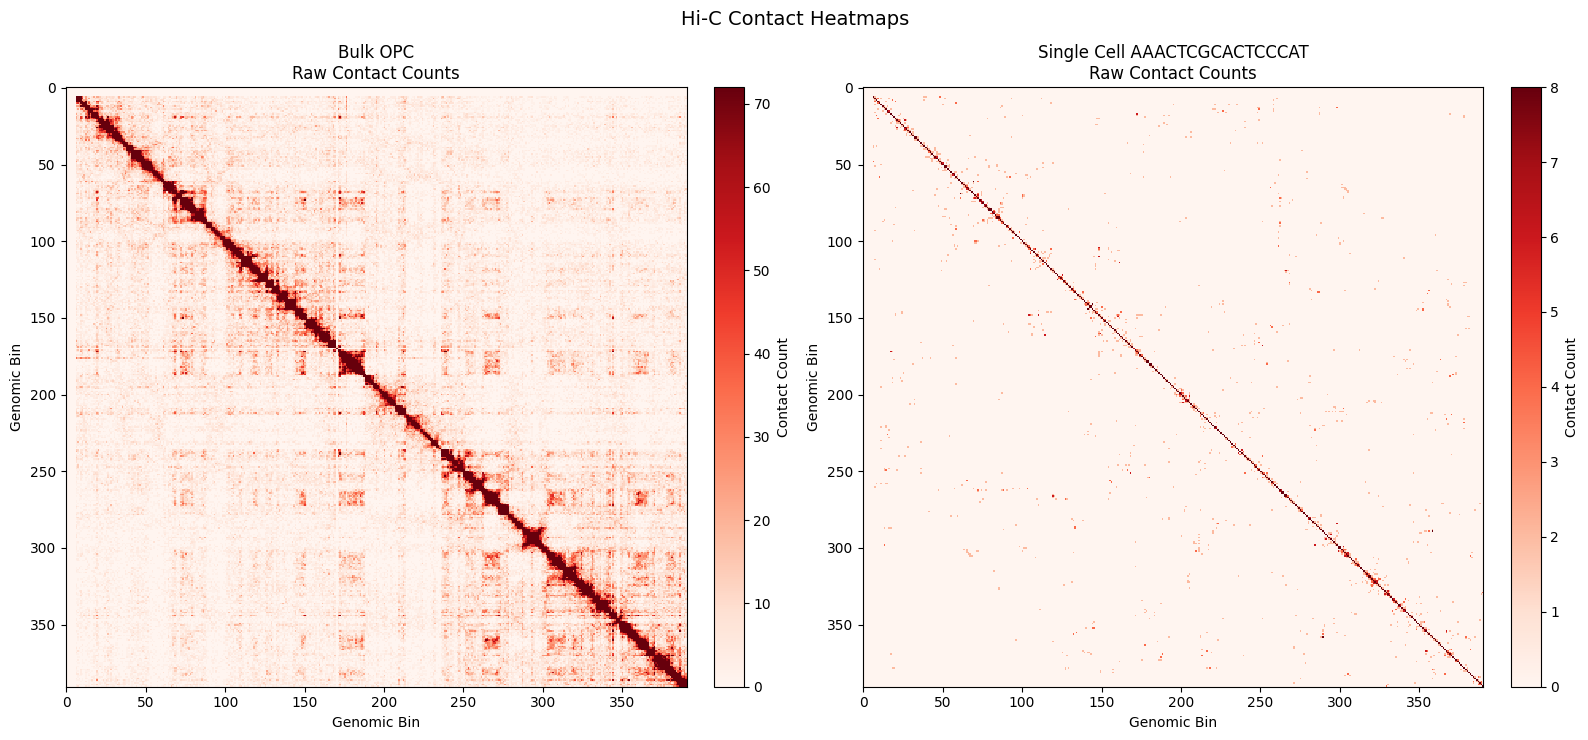

In [21]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon Oct  6 01:01:23 2025

@author: mozhganoroujlu
"""

import cooler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

def load_cooler_matrix(cool_path, region=None):
    clr = cooler.Cooler(cool_path)
    if region is None:
        mat = clr.matrix(balance=False)[:]          # Raw counts
    else:
        mat = clr.matrix(balance=False).fetch(region)
    return mat, clr

def plot_contact_heatmap(ax, mat, title, is_single_cell=False):
    """Plot heatmap ignoring diagonal for scaling"""
    # Copy matrix and zero out the diagonal for scaling purposes
    mat_for_scaling = mat.copy()
    np.fill_diagonal(mat_for_scaling, 0)
    
    nonzero = mat_for_scaling[mat_for_scaling > 0]
    
    if len(nonzero) > 0:
        if is_single_cell:
            # More aggressive for sparse single-cell data
            vmax = np.percentile(nonzero, 99.0)
            if vmax < 5:  # fallback if extremely sparse
                vmax = np.percentile(nonzero, 99.9)
        else:
            vmax = np.percentile(nonzero, 98)
    else:
        vmax = 10
    
    im = ax.imshow(mat, cmap='Reds', origin='upper', 
                   vmax=vmax, aspect='auto', interpolation='nearest')
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Genomic Bin')
    ax.set_ylabel('Genomic Bin')
    
    cbar = plt.colorbar(im, ax=ax, label='Contact Count', fraction=0.046, pad=0.04)
    return im

def main():
    # ================== UPDATE THESE ==================
    bulk_cool_path = '/.OPC.cool'          # Path to the bulk .cool file
    single_cell_cool_dir = '/.cool_single_cell/'  # Folder with single-cell .cool files
    barcode_celltype_tsv = '/.non_neuron.tsv' # TSV with 'barcode' and 'celltype' columns
    
    cell_type = 'OPC'          # Change as needed
    # =================================================
    
    # Load mapping
    df = pd.read_csv(barcode_celltype_tsv, sep='\t')
    matching = df[df['celltype'] == cell_type]
    if len(matching) == 0:
        raise ValueError(f"No barcode found for cell type '{cell_type}'")
    
    barcode = matching.iloc[0]['barcode']
    print(f"Selected barcode for {cell_type}: {barcode}")
    
    # Find single-cell .cool file
    single_cell_cool_path = None
    for f in Path(single_cell_cool_dir).rglob('*.cool'):
        if barcode in f.name or barcode in str(f):
            single_cell_cool_path = str(f)
            break
    
    if not single_cell_cool_path:
        raise FileNotFoundError(f"Could not find .cool file for barcode {barcode}")
    
    
    
    # Load matrices
    bulk_mat, bulk_clr = load_cooler_matrix(bulk_cool_path)
    sc_mat, sc_clr = load_cooler_matrix(single_cell_cool_path)
    
    print(f"Bulk resolution: {bulk_clr.binsize} bp")
    print(f"Single-cell resolution: {sc_clr.binsize} bp")
    print(f"Bulk matrix shape: {bulk_mat.shape}")
    print(f"Single-cell matrix shape: {sc_mat.shape}")
    
    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(16, 7.5))
    
    plot_contact_heatmap(axs[0], bulk_mat, f'Bulk {cell_type}\nRaw Contact Counts', is_single_cell=False)
    plot_contact_heatmap(axs[1], sc_mat, f'Single Cell {barcode}\nRaw Contact Counts', is_single_cell=True)
    
    plt.suptitle('Hi-C Contact Heatmaps', fontsize=14)
    plt.tight_layout()
    
    output_file = f'{cell_type}_vs_single_cell_heatmaps.pdf'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Figure saved: {output_file}")
    plt.show()

if __name__ == "__main__":
    main()